In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/tanzania.csv")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [4]:
# Add country column
df["Country"] = "Tanzania"

# Convert YEAR + DOY into proper date
df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

# Extract month
df["Month"] = df["Date"].dt.month

# Check result
df[["YEAR", "DOY", "Date", "Month", "Country"]].head()

,YEAR,DOY,Date,Month,Country
0,2015,1,2015-01-01,1,Tanzania
1,2015,2,2015-01-02,1,Tanzania
2,2015,3,2015-01-03,1,Tanzania
3,2015,4,2015-01-04,1,Tanzania
4,2015,5,2015-01-05,1,Tanzania


In [5]:
# Replace -999 with NaN
df.replace(-999, np.nan, inplace=True)

print("Missing values after replacing -999:")
print(df.isna().sum())

print("\n----------------------")

# Check duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Drop duplicates if found
df = df.drop_duplicates()

print("\nDataset shape after removing duplicates:")
print(df.shape)

Missing values after replacing -999:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

----------------------
Number of duplicate rows: 0

Dataset shape after removing duplicates:
(4108, 15)


Data Cleaning


Replaced invalid -999 values with NaN.


No missing values were found.


No duplicate rows were found.


Dataset contains 4,108 records after cleaning.


Insight
The Tanzania dataset was clean and ready for analysis.

In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


In [7]:
df.describe(include=[np.number])

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,6.423564
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,3.477046
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,12.000000


Descriptive Statistics
Average temperature: ~26.8°C
Maximum temperature: ~33.93°C
Minimum temperature: ~20.03°C
Average rainfall: ~3.74 mm
Average humidity: ~77.13%
Maximum wind speed: ~11.74 m/s
Insight

Tanzania experiences warm temperatures, high humidity, and higher rainfall compared to Kenya and Sudan.

In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Percentage Per Column:")
print(missing_percentage)

print("\nColumns with more than 5% missing values:")
print(missing_percentage[missing_percentage > 5])

Missing Percentage Per Column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
Date           0.0
Month          0.0
dtype: float64

Columns with more than 5% missing values:
Series([], dtype: float64)


Missing Value Analysis
Missing values in all columns: 0%
No column had more than 5% missing values.
Insight

The Tanzania dataset had no missing values, so no additional missing value treatment was required.

In [9]:
from scipy.stats import zscore

columns_to_check = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

z_scores = df[columns_to_check].apply(zscore)

outliers = (abs(z_scores) > 3).any(axis=1)

print("Number of outlier rows:")
print(outliers.sum())

Number of outlier rows:
97


Outlier Analysis
Detected 97 outlier rows using the Z-score method.
Insight

These outliers may represent extreme weather conditions such as heavy rainfall or unusual temperature changes, so they were retained for analysis.

In [10]:
# Drop rows where more than 30% values are missing
threshold = int(df.shape[1] * 0.7)
df = df.dropna(thresh=threshold)

# Forward fill remaining missing values
df = df.ffill()

print("Remaining missing values:")
print(df.isna().sum())

Remaining missing values:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


### Missing Value Handling

Dropped rows with more than 30% missing values.
Applied forward fill for remaining missing values.
Final dataset has 0 missing values in all columns.
Insight

The dataset is fully cleaned and ready for further analysis.

In [11]:
df.to_csv("../data/tanzania_clean.csv", index=False)

print("Cleaned Tanzania  dataset exported successfully!")

Cleaned Tanzania  dataset exported successfully!


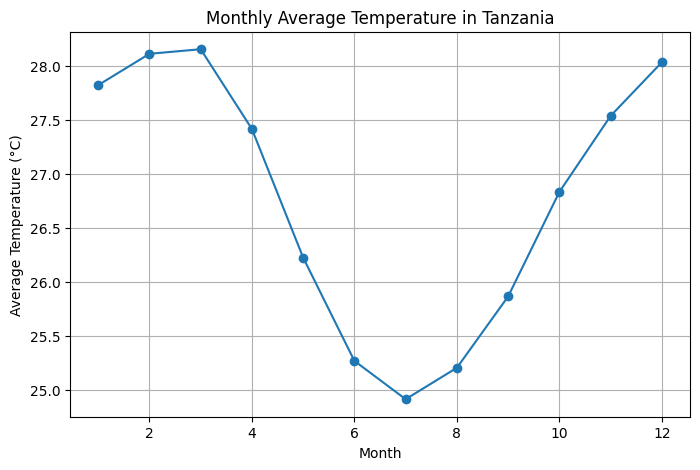

In [12]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(8,5))
monthly_temp.plot(marker="o")
plt.title("Monthly Average Temperature in Tanzania")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

### Monthly Temperature Trend Interpretation

Temperature increases from January to March.
March (Month 3) is the warmest month at approximately 28.2°C.
Temperature decreases from April to July.
July (Month 7) is the coolest month at approximately 24.9°C.
Temperature rises again from August to December.
Insight

Tanzania experiences warm temperatures throughout the year with a cooler mid-year period and warmer conditions at the beginning and end of the year.

In [13]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

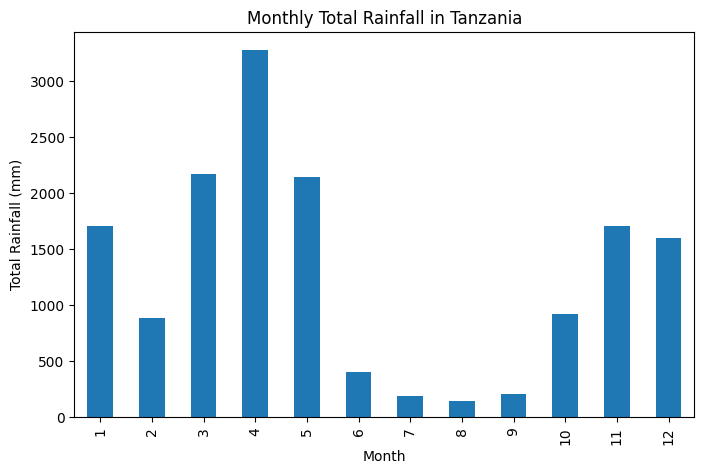

In [14]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(8,5))
monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall in Tanzania")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.show()

### Rainfall Trend Interpretation
Rainfall is highest in April (Month 4) with about 3,300 mm.
March and May also record high rainfall levels.
Rainfall decreases significantly from June to September.
July and August are the driest months.
Rainfall increases again from October to December.
Insight

Tanzania shows strong seasonal rainfall patterns with heavy rainfall in spring months and dry conditions during mid-year months.

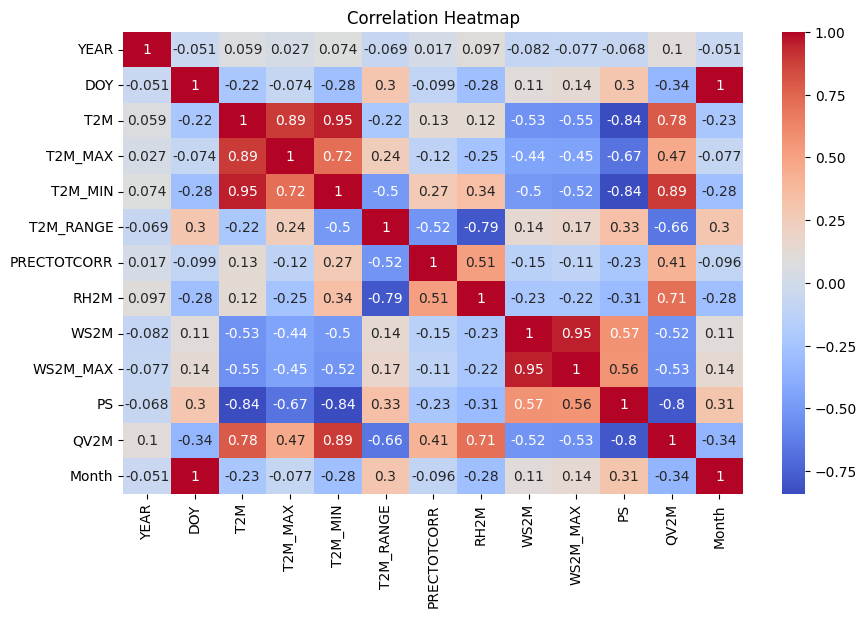

In [15]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Interpretation

Strong correlations identified in the Tanzania dataset include:

T2M and T2M_MIN = 0.95
Higher average temperatures are strongly associated with higher minimum temperatures.
WS2M and WS2M_MAX = 0.95
Average wind speed strongly increases with maximum wind speed.
T2M and T2M_MAX = 0.89
Higher average temperatures are also linked with higher maximum temperatures.
Insight

The heatmap shows strong relationships between temperature-related variables and wind-related variables, which is expected in climate datasets.

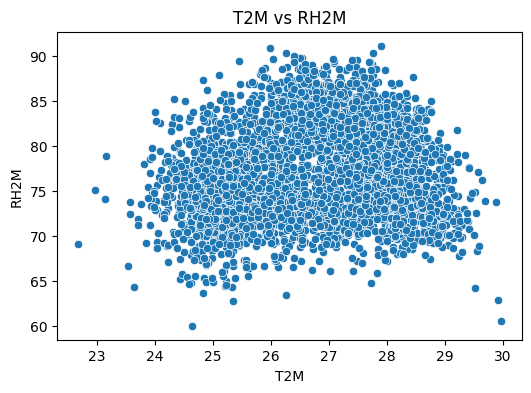

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("T2M vs RH2M")
plt.show()

### Scatter Plot Interpretation: Temperature vs Humidity

The scatter plot shows a weak positive relationship between temperature and humidity.
Most temperature values are concentrated between 25°C and 29°C.
Humidity remains relatively high, mostly between 70% and 85%.
There are few extreme values outside the normal range.
Insight

Tanzania generally experiences warm temperatures with consistently high humidity levels, which supports its tropical climate pattern.

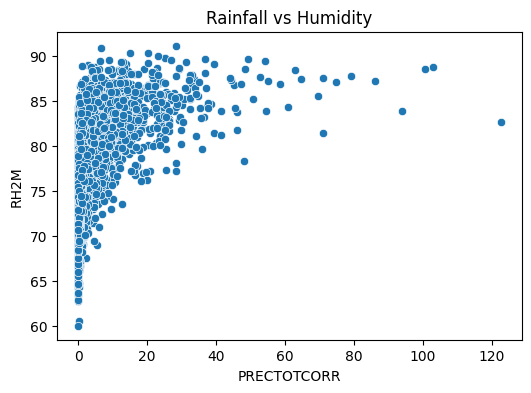

In [17]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="PRECTOTCORR", y="RH2M")
plt.title("Rainfall vs Humidity")
plt.show()

### Scatter Plot Interpretation: Rainfall vs Humidity

The scatter plot shows a positive relationship between rainfall and humidity.
Higher rainfall amounts mostly occur when humidity levels are high (above 75%).
Most rainfall values are concentrated at lower levels, with a few extreme rainfall events.
Very heavy rainfall occurs less frequently.
Insight

This suggests that rainfall in Tanzania is more likely during highly humid conditions, which reflects the country’s tropical rainfall pattern.

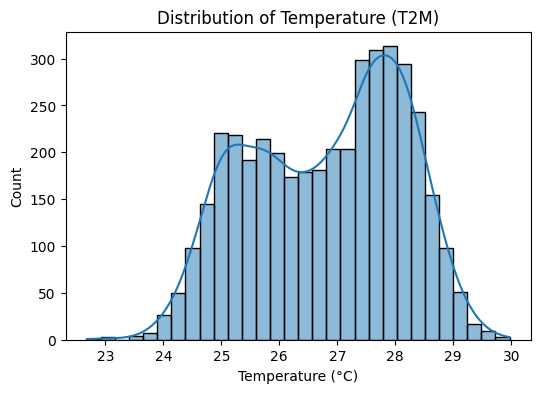

In [18]:
plt.figure(figsize=(6,4))
sns.histplot(df["T2M"], bins=30, kde=True)
plt.title("Distribution of Temperature (T2M)")
plt.xlabel("Temperature (°C)")
plt.show()

### Temperature Distribution Interpretation

The temperature distribution is concentrated between 25°C and 29°C.
Most temperature values peak around 27°C–28°C.
The distribution appears slightly bimodal, showing two small peaks.
Extreme low and high temperatures occur less frequently.
Insight

This indicates that Tanzania experiences consistently warm temperatures throughout the year with limited temperature variation.

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

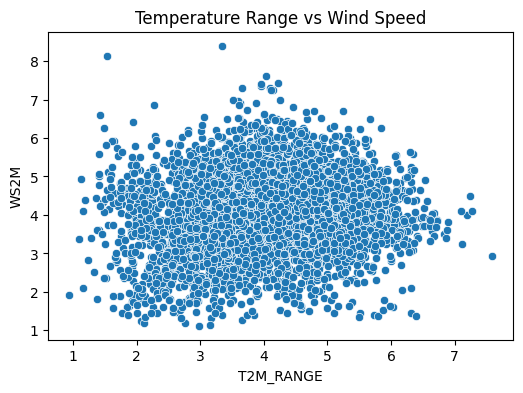

In [20]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["T2M_RANGE"], y=df["WS2M"])
plt.title("Temperature Range vs Wind Speed")
plt.xlabel("T2M_RANGE")
plt.ylabel("WS2M")
plt.show()

### Temperature Range vs Wind Speed Insight

The scatter plot shows a weak relationship between temperature range and wind speed.
Most temperature range values are between 2°C and 6°C.
Wind speed is mostly concentrated between 2 m/s and 6 m/s.
A few extreme wind speed values are present but are rare.
Insight

Wind speed in Tanzania does not appear to be strongly affected by temperature range.

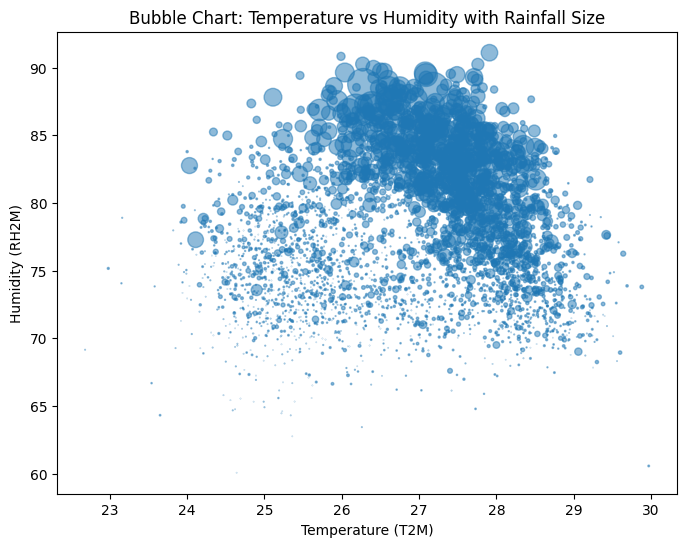

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*5,
    alpha=0.5
)

plt.title("Bubble Chart: Temperature vs Humidity with Rainfall Size")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()

### Bubble Chart Insight

The chart shows a relationship between temperature, humidity, and rainfall.
Larger bubbles represent higher rainfall levels.
Most heavy rainfall events occur when humidity is high (above 80%).
Most temperatures are concentrated between 26°C and 28°C.
Insight

Tanzania experiences higher rainfall during warm and highly humid conditions, which reflects its tropical climate pattern.

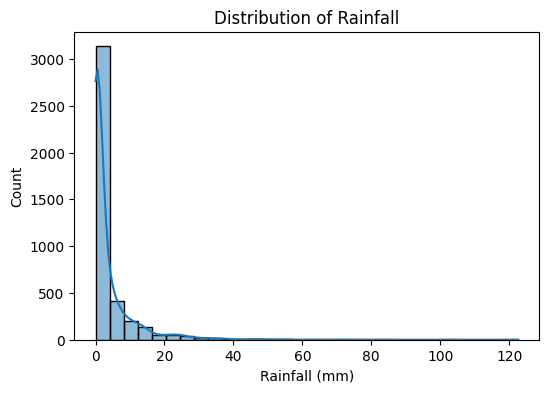

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(df["PRECTOTCORR"], bins=30, kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.show()

### Rainfall Distribution Interpretation

The rainfall distribution is highly right-skewed.
Most days record very low or no rainfall, as shown by the high concentration of values near 0 mm.
A smaller number of days experience moderate to heavy rainfall events.
Rainfall occasionally reaches extreme values of over 120 mm, indicating rare heavy storms.
Insight

This suggests that Tanzania experiences frequent dry days with occasional intense rainfall events, which reflects its seasonal rainfall pattern.

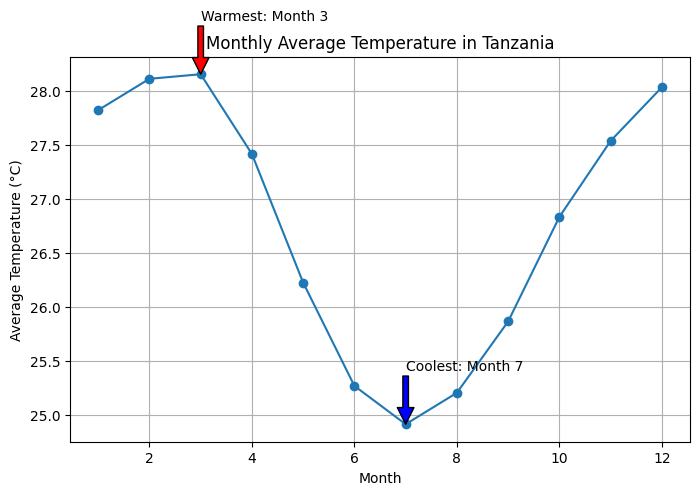

In [23]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(8,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")

# Find warmest month
warmest_month = monthly_temp.idxmax()
warmest_temp = monthly_temp.max()

# Find coolest month
coolest_month = monthly_temp.idxmin()
coolest_temp = monthly_temp.min()

# Annotate warmest month
plt.annotate(
    f"Warmest: Month {warmest_month}",
    xy=(warmest_month, warmest_temp),
    xytext=(warmest_month, warmest_temp+0.5),
    arrowprops=dict(facecolor='red')
)

# Annotate coolest month
plt.annotate(
    f"Coolest: Month {coolest_month}",
    xy=(coolest_month, coolest_temp),
    xytext=(coolest_month, coolest_temp+0.5),
    arrowprops=dict(facecolor='blue')
)

plt.title("Monthly Average Temperature in Tanzania")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

### Monthly Temperature Trend Interpretation

Temperature increases from January to March.
March (Month 3) is the warmest month at approximately 28.2°C.
Temperature decreases from April to July.
July (Month 7) is the coolest month at approximately 24.9°C.
Temperature rises again from August to December.
Insight

Tanzania maintains warm temperatures throughout the year with a cooler mid-year season and warmer conditions at the beginning and end of the year.

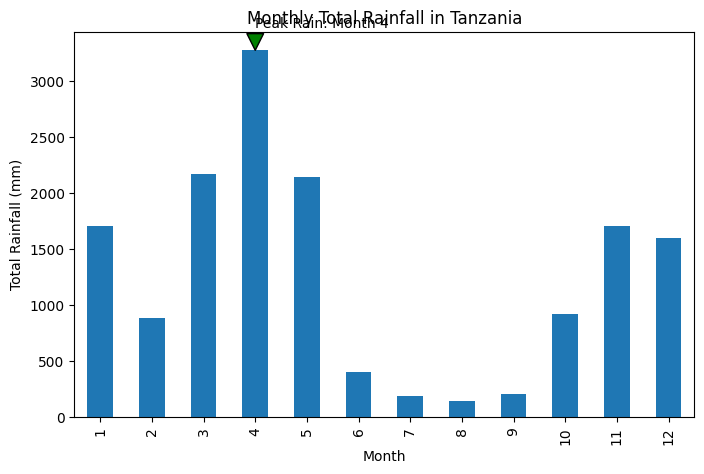

In [24]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.figure(figsize=(8,5))
monthly_rain.plot(kind="bar")

# Peak rainfall month
peak_month = monthly_rain.idxmax()
peak_rain = monthly_rain.max()

plt.annotate(
    f"Peak Rain: Month {peak_month}",
    xy=(peak_month-1, peak_rain),
    xytext=(peak_month-1, peak_rain+200),
    arrowprops=dict(facecolor='green')
)

plt.title("Monthly Total Rainfall in Tanzania")
plt.xlabel("Month")
plt.ylabel("Total Rainfall (mm)")
plt.show()

### Monthly Rainfall Trend Interpretation

Rainfall increases from January to April.
April (Month 4) records the highest rainfall.
Rainfall drops significantly from June to September.
July and August are the driest months.
Rainfall increases again from October to December.
Insight

Tanzania experiences clear wet and dry seasons, with heavy rainfall in April and very low rainfall during mid-year months.

# Final EDA Summary

## Data Cleaning

- Loaded Tanzania climate dataset successfully.
Converted YEAR and DOY into a proper Date column.
Created a Month column for monthly analysis.
Replaced invalid -999 values with NaN.
No missing values remained after cleaning.
No duplicate rows were found.
Cleaned dataset was exported successfully.

## Descriptive Statistics
-Dataset contains 4,108 records.
Average temperature: 26.8°C
Average humidity: 77.1%
Average rainfall: 3.74 mm
Average wind speed: 4.1 m/s

## Outlier Analysis
Detected 97 outlier rows using the Z-score method.
These likely represent extreme rainfall or unusual weather conditions.

## Monthly Trends
-March is the warmest month.
July is the coolest month.
Rainfall peaks in April.
July–August are the driest months.

## Correlation Insights
- Temperature strongly correlates with minimum temperature.
Wind speed strongly correlates with maximum wind speed.
Rainfall and humidity show a positive relationship.

## Distribution Insights
- Temperature is mostly concentrated between 25°C–28°C.
Rainfall is highly right-skewed with many dry days and few heavy rainfall events.
## Conclusion
Tanzania has a warm and humid climate with clear wet and dry seasons. Heavy rainfall occurs mainly in April, while temperatures remain relatively stable throughout the year.